# Interpretación del modelo seleccionado

**Autora:** Leydy Osorio Vargas  
**Fecha:** 2026-09-08

## Descripción

Este notebook corresponde a la Tarea 7. Interpreta el pipeline Random Forest seleccionado en la Tarea 6, identifica los atributos más relevantes, caracteriza los errores y propone experimentos para una siguiente iteración.

Se estudian explicaciones globales y diagnósticos agregados. Las asociaciones observadas no implican causalidad ni convierten el modelo en una herramienta clínica.


## Alcance y precauciones

- Se carga el artefacto `models/heart_disease_best_pipeline.joblib`; no se selecciona otro modelo.
- Se reconstruye exactamente la partición de la Tarea 6 para comprobar reproducibilidad.
- La importancia por impureza se contrasta con permutación porque ambas responden preguntas diferentes y tienen sesgos.
- El análisis de errores muestra únicamente estadísticas agregadas, nunca registros individuales.
- El análisis de umbrales es exploratorio; elegir un umbral con el test produciría sesgo y debe hacerse después mediante validación cruzada y calibración.


## 📚 Importar librerías y configurar reproducibilidad


In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, learning_curve, train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
PARALLEL_JOBS = 1
TARGET = "disease"
POSITIVE_CLASS = 1
NEGATIVE_CLASS = 0
DEFAULT_THRESHOLD = 0.50
BOOTSTRAP_SAMPLES = 2000
CONFIDENCE_LOWER_PERCENTILE = 2.5
CONFIDENCE_UPPER_PERCENTILE = 97.5
TOP_TRANSFORMED_FEATURES = 15
TOP_CONCEPTUAL_FEATURES = 12
PERMUTATION_REPEATS = 30
LEARNING_CURVE_POINTS = 5
EXPECTED_TEST_ROWS = 96
EXPECTED_TARGET_CLASSES = 2
EXPECTED_FALSE_NEGATIVES = 5

print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib: {joblib.__version__}")

Pandas: 3.0.5
Scikit-learn: 1.9.0
Joblib: 1.6.0


## 💾 Cargar el dataset y el pipeline ganador


In [2]:
PROJECT_DIR = Path.cwd().resolve()

if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = next(
        parent
        for parent in PROJECT_DIR.parents
        if (parent / "data").is_dir() and (parent / "pyproject.toml").exists()
    )

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from heart_project import HeartFeatureEngineer  # noqa: E402, F401

INTERMEDIATE_FILE = PROJECT_DIR / "data" / "02_intermediate" / "corazon_type_fixed.parquet"
MODEL_FILE = PROJECT_DIR / "models" / "heart_disease_best_pipeline.joblib"

if not INTERMEDIATE_FILE.exists():
    raise FileNotFoundError("No se encontró el Parquet intermedio de la Tarea 2.")
if not MODEL_FILE.exists():
    raise FileNotFoundError("No se encontró el pipeline entrenado de la Tarea 6.")

heart_df = pd.read_parquet(INTERMEDIATE_FILE)
unique_df = heart_df.drop_duplicates().copy()
modeling_df = unique_df.loc[unique_df[TARGET].notna()].copy()
winner_pipeline = joblib.load(MODEL_FILE)

artifact_summary = pd.Series(
    {
        "dataset_rows": len(heart_df),
        "modeling_rows_after_deduplication": len(modeling_df),
        "artifact_path": str(MODEL_FILE.relative_to(PROJECT_DIR)),
        "artifact_size_kb": MODEL_FILE.stat().st_size / 1024,
        "pipeline_steps": list(winner_pipeline.named_steps),
        "selected_model": type(winner_pipeline.named_steps["model"]).__name__,
    }
)

artifact_summary

dataset_rows                                                              3030
modeling_rows_after_deduplication                                          480
artifact_path                        models/heart_disease_best_pipeline.joblib
artifact_size_kb                                                   1648.651367
pipeline_steps                                               [features, model]
selected_model                                          RandomForestClassifier
dtype: object

## 🔁 Comprobar la reproducción del resultado final


In [3]:
X = modeling_df.drop(columns=TARGET)
y = modeling_df[TARGET].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

test_prediction = winner_pipeline.predict(X_test)
test_probability = winner_pipeline.predict_proba(X_test)[:, POSITIVE_CLASS]
tn, fp, fn, tp = confusion_matrix(y_test, test_prediction).ravel()

reproduced_metrics = pd.Series(
    {
        "recall": recall_score(y_test, test_prediction),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_test, test_prediction),
        "f1": f1_score(y_test, test_prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
        "roc_auc": roc_auc_score(y_test, test_probability),
        "false_negatives": fn,
        "false_positives": fp,
    },
    name="Random Forest",
)

reproduced_metrics.to_frame().round(4)

,Random Forest
recall,0.8913
specificity,0.8200
precision,0.8200
f1,0.8542
balanced_accuracy,0.8557
roc_auc,0.9265
false_negatives,5.0000
false_positives,9.0000


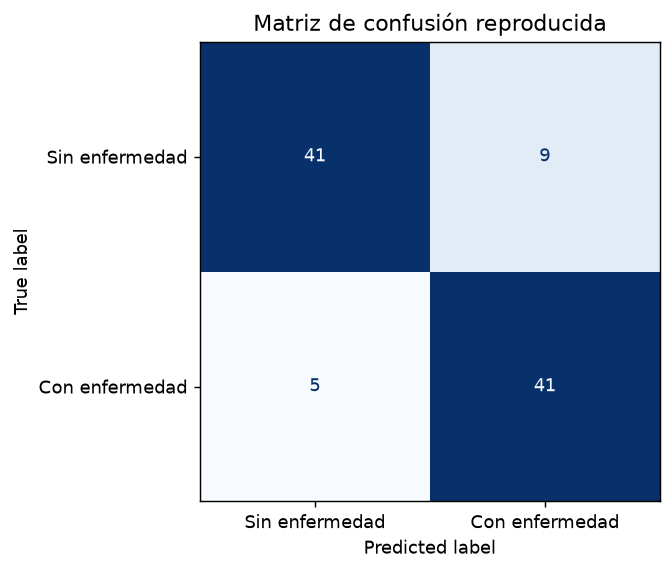

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Sin enfermedad", "Con enfermedad"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión reproducida")
plt.tight_layout()

El artefacto reproduce el resultado de la Tarea 6: detecta 41 de 46 casos positivos y deja 5 falsos negativos. Esta comprobación garantiza que la interpretación corresponde al modelo realmente persistido.


## 1. Comprender la estructura del modelo


In [5]:
feature_pipeline = winner_pipeline.named_steps["features"]
random_forest = winner_pipeline.named_steps["model"]
transformed_feature_names = feature_pipeline.get_feature_names_out()

model_structure = pd.Series(
    {
        "model_family": type(random_forest).__name__,
        "number_of_trees": random_forest.n_estimators,
        "maximum_depth": random_forest.max_depth,
        "minimum_samples_per_leaf": random_forest.min_samples_leaf,
        "class_weight": random_forest.class_weight,
        "input_features": X_train.shape[1],
        "transformed_features": len(transformed_feature_names),
    }
)

model_structure

model_family                RandomForestClassifier
number_of_trees                                250
maximum_depth                                 None
minimum_samples_per_leaf                         3
class_weight                              balanced
input_features                                  13
transformed_features                            46
dtype: object

Random Forest combina 250 árboles y promedia sus decisiones. Puede representar relaciones no lineales e interacciones, pero su explicación no es una única regla. Por eso se utilizan varias vistas complementarias.


## 2. Importancia incorporada en los árboles


In [6]:
impurity_importance = (
    pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names,
            "impurity_importance": random_forest.feature_importances_,
        }
    )
    .sort_values("impurity_importance", ascending=False)
    .reset_index(drop=True)
)

impurity_importance.head(TOP_TRANSFORMED_FEATURES).round(4)

,transformed_feature,impurity_importance
0,numeric__ca,0.1125
1,nominal__thal_normal,0.0929
2,nominal__thal_reversable,0.0743
3,numeric__old_peak_slope_interaction,0.0704
4,numeric__old_peak,0.0689
5,numeric__max_hr,0.0561
6,numeric__age,0.0525
7,numeric__age_squared,0.0464
8,nominal__chest_pain_asymptomatic,0.0463
9,numeric__max_hr_old_peak_interaction,0.0426


In [7]:
conceptual_features = [
    "old_peak_slope_interaction",
    "max_hr_old_peak_interaction",
    "chest_pain_exang",
    "age_squared",
    "chest_pain",
    "rest_ecg",
    "old_peak",
    "max_hr",
    "rest_bp",
    "thal",
    "sex",
    "fbs",
    "exang",
    "slope",
    "chol",
    "age",
    "ca",
]

grouped_rows = []
for transformed_name, importance_value in zip(
    transformed_feature_names, random_forest.feature_importances_, strict=True
):
    clean_name = transformed_name.split("__", maxsplit=1)[-1]
    clean_name = clean_name.removeprefix("missingindicator_")
    conceptual_name = next(
        (
            feature
            for feature in conceptual_features
            if clean_name == feature or clean_name.startswith(f"{feature}_")
        ),
        clean_name,
    )
    grouped_rows.append(
        {
            "conceptual_feature": conceptual_name,
            "impurity_importance": importance_value,
        }
    )

grouped_impurity = (
    pd.DataFrame(grouped_rows)
    .groupby("conceptual_feature", as_index=False)["impurity_importance"]
    .sum()
    .sort_values("impurity_importance", ascending=False)
)

grouped_impurity.head(TOP_CONCEPTUAL_FEATURES).round(4)

,conceptual_feature,impurity_importance
16,thal,0.1731
2,ca,0.1178
3,chest_pain,0.0871
4,chest_pain_exang,0.0776
11,old_peak_slope_interaction,0.0765
10,old_peak,0.0734
8,max_hr,0.0593
0,age,0.0529
1,age_squared,0.0468
9,max_hr_old_peak_interaction,0.0453


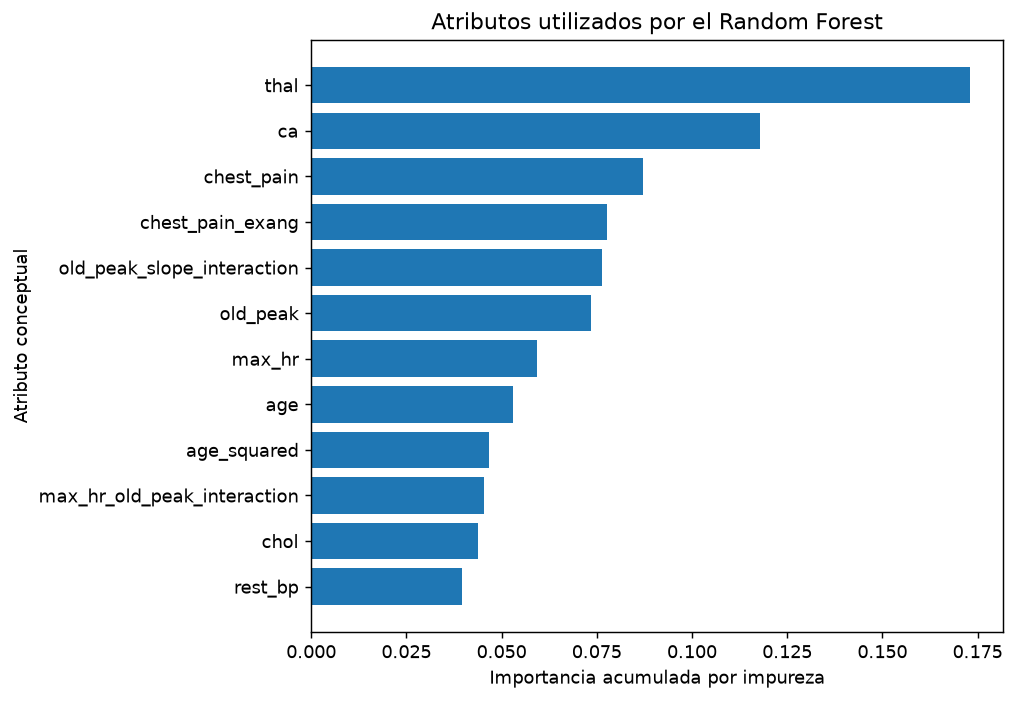

In [8]:
plot_data = grouped_impurity.head(TOP_CONCEPTUAL_FEATURES).sort_values("impurity_importance")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(plot_data["conceptual_feature"], plot_data["impurity_importance"])
ax.set(
    xlabel="Importancia acumulada por impureza",
    ylabel="Atributo conceptual",
    title="Atributos utilizados por el Random Forest",
)
plt.tight_layout()

La importancia por impureza muestra cuánto utilizaron los árboles cada atributo para separar observaciones. Puede favorecer variables continuas o con muchas posibilidades de corte y repartir importancia entre variables relacionadas; por eso no se interpreta sola.


## 3. Importancia por permutación sobre variables originales


In [9]:
permutation_result = permutation_importance(
    winner_pipeline,
    X_test,
    y_test,
    scoring="recall",
    n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=PARALLEL_JOBS,
)

permutation_summary = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "recall_importance_mean": permutation_result.importances_mean,
            "recall_importance_std": permutation_result.importances_std,
        }
    )
    .sort_values("recall_importance_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_summary.round(4)

,feature,recall_importance_mean,recall_importance_std
0,thal,0.0645,0.0370
1,age,0.0188,0.0166
2,chest_pain,0.0065,0.0246
3,chol,0.0000,0.0000
4,rest_bp,0.0000,0.0000
5,slope,0.0000,0.0000
6,fbs,0.0000,0.0000
7,rest_ecg,0.0000,0.0000
8,exang,-0.0007,0.0173
9,sex,-0.0043,0.0163


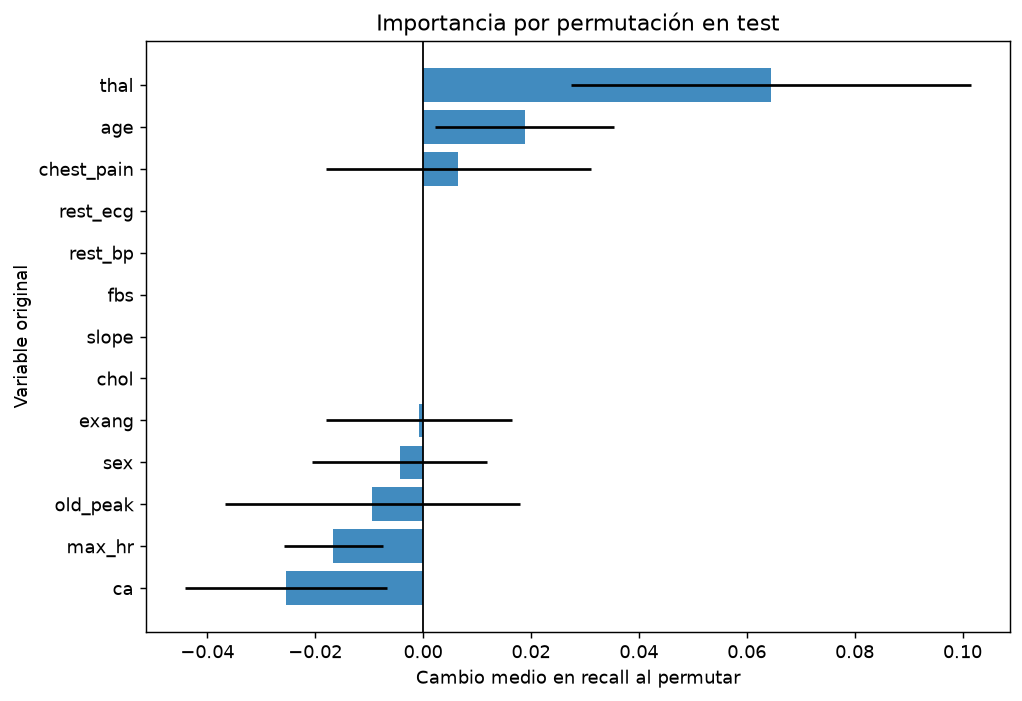

In [10]:
permutation_plot = permutation_summary.sort_values("recall_importance_mean")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(
    permutation_plot["feature"],
    permutation_plot["recall_importance_mean"],
    xerr=permutation_plot["recall_importance_std"],
    alpha=0.85,
)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    xlabel="Cambio medio en recall al permutar",
    ylabel="Variable original",
    title="Importancia por permutación en test",
)
plt.tight_layout()

`thal` es la señal más consistente: permutarla reduce el recall en aproximadamente 0,064. `age` y `chest_pain` aportan señales menores. Los valores cercanos a cero o negativos no prueban irrelevancia; con solo 96 observaciones y atributos correlacionados, la estimación es inestable. Debe validarse en nuevas muestras.


## 4. Incertidumbre de las métricas


In [11]:
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_rows = []
y_test_array = y_test.to_numpy()

for _ in range(BOOTSTRAP_SAMPLES):
    sample_positions = rng.integers(0, len(y_test_array), len(y_test_array))
    sampled_actual = y_test_array[sample_positions]
    sampled_prediction = test_prediction[sample_positions]
    if len(np.unique(sampled_actual)) < EXPECTED_TARGET_CLASSES:
        continue
    sample_tn, sample_fp, sample_fn, sample_tp = confusion_matrix(
        sampled_actual,
        sampled_prediction,
        labels=[NEGATIVE_CLASS, POSITIVE_CLASS],
    ).ravel()
    bootstrap_rows.append(
        {
            "recall": sample_tp / (sample_tp + sample_fn),
            "specificity": sample_tn / (sample_tn + sample_fp),
        }
    )

bootstrap_metrics = pd.DataFrame(bootstrap_rows)
uncertainty_summary = pd.DataFrame(
    {
        "estimate": [reproduced_metrics["recall"], reproduced_metrics["specificity"]],
        "ci_95_lower": bootstrap_metrics.quantile(CONFIDENCE_LOWER_PERCENTILE / 100),
        "ci_95_upper": bootstrap_metrics.quantile(CONFIDENCE_UPPER_PERCENTILE / 100),
    },
    index=["recall", "specificity"],
)

uncertainty_summary.round(4)

,estimate,ci_95_lower,ci_95_upper
recall,0.8913,0.7959,0.9762
specificity,0.8200,0.7083,0.9268


Los intervalos bootstrap reflejan la incertidumbre del test pequeño. Son descriptivos y no sustituyen una validación externa: el rendimiento real puede variar al cambiar la población o la calidad de captura.


## 5. ¿Qué errores comete el modelo?


In [12]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test
error_analysis["predicted"] = test_prediction
error_analysis["probability_positive"] = test_probability
error_analysis["error_type"] = np.select(
    [
        (y_test == POSITIVE_CLASS) & (test_prediction == NEGATIVE_CLASS),
        (y_test == NEGATIVE_CLASS) & (test_prediction == POSITIVE_CLASS),
        (y_test == POSITIVE_CLASS) & (test_prediction == POSITIVE_CLASS),
    ],
    ["FN", "FP", "TP"],
    default="TN",
)
error_analysis["missing_predictors"] = X_test.isna().sum(axis=1)

numeric_diagnostics = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]
q1 = X_train[numeric_diagnostics].quantile(0.25)
q3 = X_train[numeric_diagnostics].quantile(0.75)
iqr = q3 - q1
outlier_flags = (X_test[numeric_diagnostics] < (q1 - 1.5 * iqr)) | (
    X_test[numeric_diagnostics] > (q3 + 1.5 * iqr)
)
error_analysis["outlier_flags"] = outlier_flags.sum(axis=1)

error_profile = error_analysis.groupby("error_type").agg(
    observations=("actual", "size"),
    probability_positive_mean=("probability_positive", "mean"),
    missing_predictors_mean=("missing_predictors", "mean"),
    outlier_flags_mean=("outlier_flags", "mean"),
    age_median=("age", "median"),
    max_hr_median=("max_hr", "median"),
    old_peak_median=("old_peak", "median"),
    ca_median=("ca", "median"),
)

error_profile.round(3)

,observations,probability_positive_mean,missing_predictors_mean,outlier_flags_mean,age_median,max_hr_median,old_peak_median,ca_median
error_type,,,,,,,,
FN,5,0.399,1.600,0.2,49.0,164.0,1.0,0.0
FP,9,0.703,3.444,0.222,59.0,147.0,1.8,0.0
TN,41,0.252,2.049,0.024,51.0,163.0,0.1,0.0
TP,41,0.821,2.244,0.22,59.0,144.0,2.6,1.0


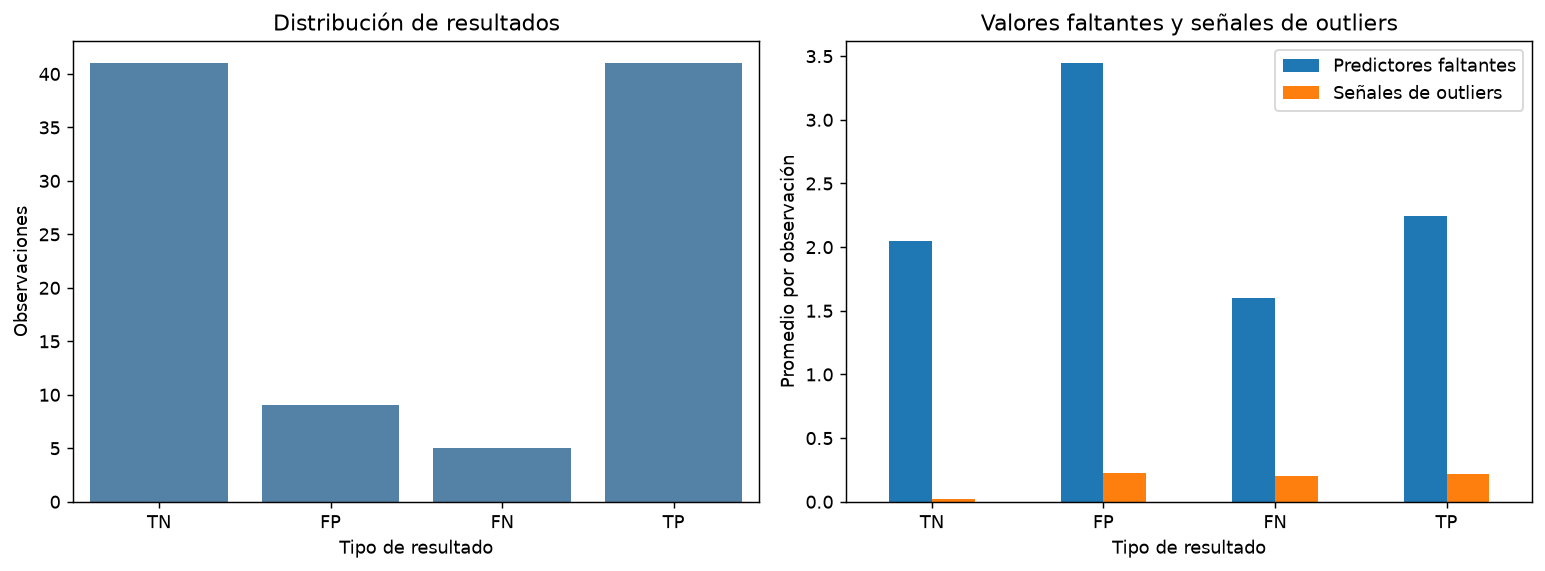

In [13]:
error_order = ["TN", "FP", "FN", "TP"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(
    x=error_profile.reindex(error_order).index,
    y=error_profile.reindex(error_order)["observations"],
    ax=axes[0],
    color="steelblue",
)
axes[0].set(xlabel="Tipo de resultado", ylabel="Observaciones", title="Distribución de resultados")

diagnostic_plot = error_profile.reindex(error_order)[
    ["missing_predictors_mean", "outlier_flags_mean"]
]
diagnostic_plot.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set(
    xlabel="Tipo de resultado",
    ylabel="Promedio por observación",
    title="Valores faltantes y señales de outliers",
)
axes[1].legend(["Predictores faltantes", "Señales de outliers"])
plt.tight_layout()

In [14]:
categorical_error_profiles = {}
for column in ["thal", "chest_pain", "exang", "sex"]:
    categorical_error_profiles[column] = (
        pd.crosstab(
            error_analysis["error_type"],
            error_analysis[column].astype("string").fillna("missing"),
            normalize="index",
        )
        .mul(100)
        .round(1)
        .reindex(error_order)
    )

categorical_error_profiles["thal"]

thal,fixed,missing,normal,reversable
error_type,,,,
TN,2.4,7.3,75.6,14.6
FP,0.0,11.1,33.3,55.6
FN,0.0,0.0,60.0,40.0
TP,9.8,12.2,9.8,68.3


### Lectura de los errores

- **Falsos negativos (5):** son la consecuencia más grave para este caso, porque una persona con etiqueta positiva podría no ser priorizada. Su probabilidad media es cercana a 0,40, lo que indica casos próximos al límite de decisión. Tres de los cinco tienen `thal=normal`, una combinación menos frecuente entre los verdaderos positivos.
- **Falsos positivos (9):** pueden producir priorizaciones o evaluaciones adicionales innecesarias. Presentan más predictores faltantes en promedio, lo que sugiere menor información disponible.
- **Outliers:** no parecen explicar por sí solos los errores; las señales son escasas y también aparecen entre aciertos.
- **Desbalance:** entrenamiento contiene 200 negativos y 184 positivos, por lo que no existe un desbalance fuerte capaz de explicar los errores.

Estos patrones son hipótesis descriptivas: cinco falsos negativos son insuficientes para afirmar una causa estable.


## 6. Sensibilidad al umbral y calibración


In [15]:
thresholds = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for threshold in thresholds:
    threshold_prediction = (test_probability >= threshold).astype(int)
    threshold_tn, threshold_fp, threshold_fn, threshold_tp = confusion_matrix(
        y_test,
        threshold_prediction,
        labels=[NEGATIVE_CLASS, POSITIVE_CLASS],
    ).ravel()
    threshold_rows.append(
        {
            "threshold": threshold,
            "recall": threshold_tp / (threshold_tp + threshold_fn),
            "specificity": threshold_tn / (threshold_tn + threshold_fp),
            "false_negatives": threshold_fn,
            "false_positives": threshold_fp,
        }
    )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.round(3)

,threshold,recall,specificity,false_negatives,false_positives
0,0.20,1.000,0.34,0,33
1,0.25,1.000,0.38,0,31
2,0.30,0.978,0.46,1,27
3,0.35,0.957,0.62,2,19
4,0.40,0.957,0.68,2,16
5,0.45,0.957,0.76,2,12
6,0.50,0.891,0.82,5,9
7,0.55,0.891,0.82,5,9
8,0.60,0.826,0.86,8,7
9,0.65,0.826,0.88,8,6


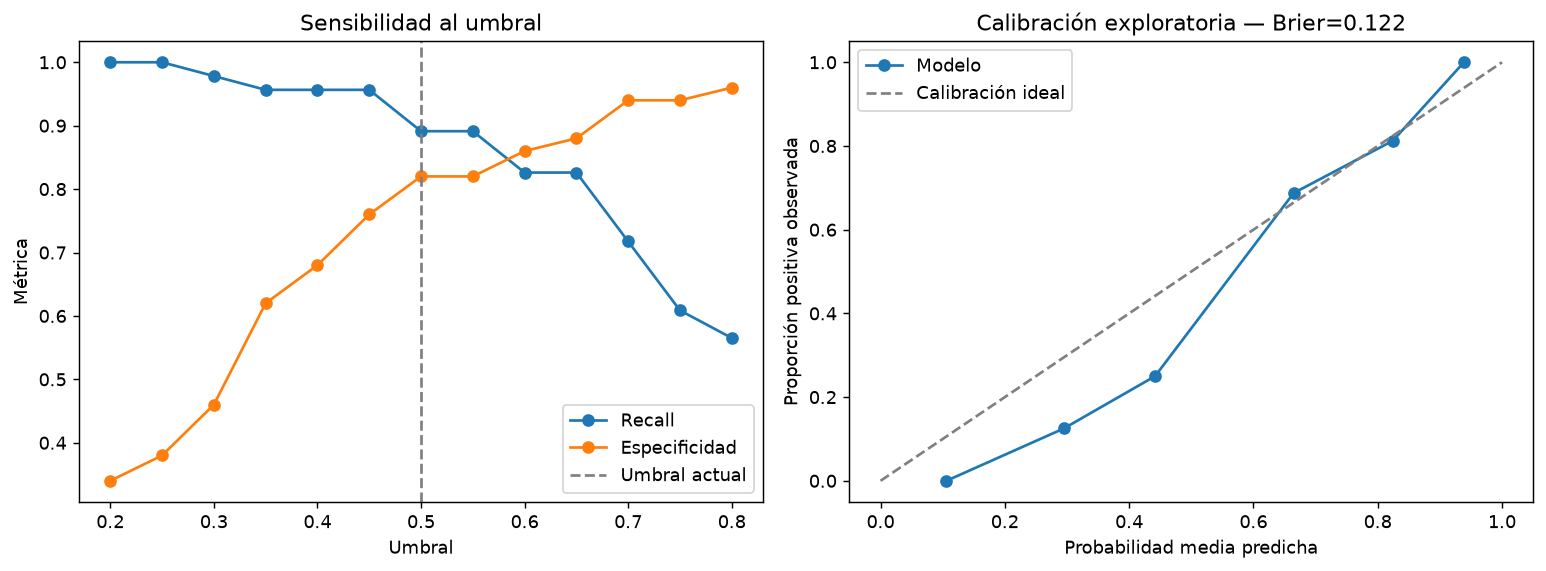

In [16]:
fraction_positive, mean_predicted_probability = calibration_curve(
    y_test,
    test_probability,
    n_bins=6,
    strategy="quantile",
)
brier_score = brier_score_loss(y_test, test_probability)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    threshold_summary["threshold"], threshold_summary["recall"], marker="o", label="Recall"
)
axes[0].plot(
    threshold_summary["threshold"],
    threshold_summary["specificity"],
    marker="o",
    label="Especificidad",
)
axes[0].axvline(DEFAULT_THRESHOLD, color="gray", linestyle="--", label="Umbral actual")
axes[0].set(xlabel="Umbral", ylabel="Métrica", title="Sensibilidad al umbral")
axes[0].legend()

axes[1].plot(mean_predicted_probability, fraction_positive, marker="o", label="Modelo")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración ideal")
axes[1].set(
    xlabel="Probabilidad media predicha",
    ylabel="Proporción positiva observada",
    title=f"Calibración exploratoria — Brier={brier_score:.3f}",
)
axes[1].legend()
plt.tight_layout()

En este test, bajar el umbral de 0,50 a 0,45 elevaría el recall de 0,891 a 0,957, pero reduciría la especificidad de 0,820 a 0,760. Este resultado **no se usa para modificar el artefacto**, porque el umbral estaría siendo elegido sobre test. El siguiente experimento debe calibrar probabilidades y seleccionar el umbral únicamente con folds de entrenamiento según costos acordados.


## 7. Curva de aprendizaje y escalabilidad


In [17]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
train_sizes, train_scores, validation_scores, fit_times, _ = learning_curve(
    clone(winner_pipeline),
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, LEARNING_CURVE_POINTS),
    cv=cv,
    scoring="recall",
    n_jobs=PARALLEL_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
    return_times=True,
)

learning_summary = pd.DataFrame(
    {
        "train_rows": train_sizes,
        "train_recall_mean": train_scores.mean(axis=1),
        "validation_recall_mean": validation_scores.mean(axis=1),
        "validation_recall_std": validation_scores.std(axis=1),
        "fit_time_mean_sec": fit_times.mean(axis=1),
    }
)

learning_summary.round(4)

,train_rows,train_recall_mean,validation_recall_mean,validation_recall_std,fit_time_mean_sec
0,61,0.9118,0.8207,0.0527,0.4978
1,122,0.9470,0.7881,0.0689,0.4541
2,184,0.9467,0.8210,0.0624,0.4902
3,245,0.9474,0.8318,0.0687,0.5789
4,307,0.9551,0.8371,0.0509,0.6843


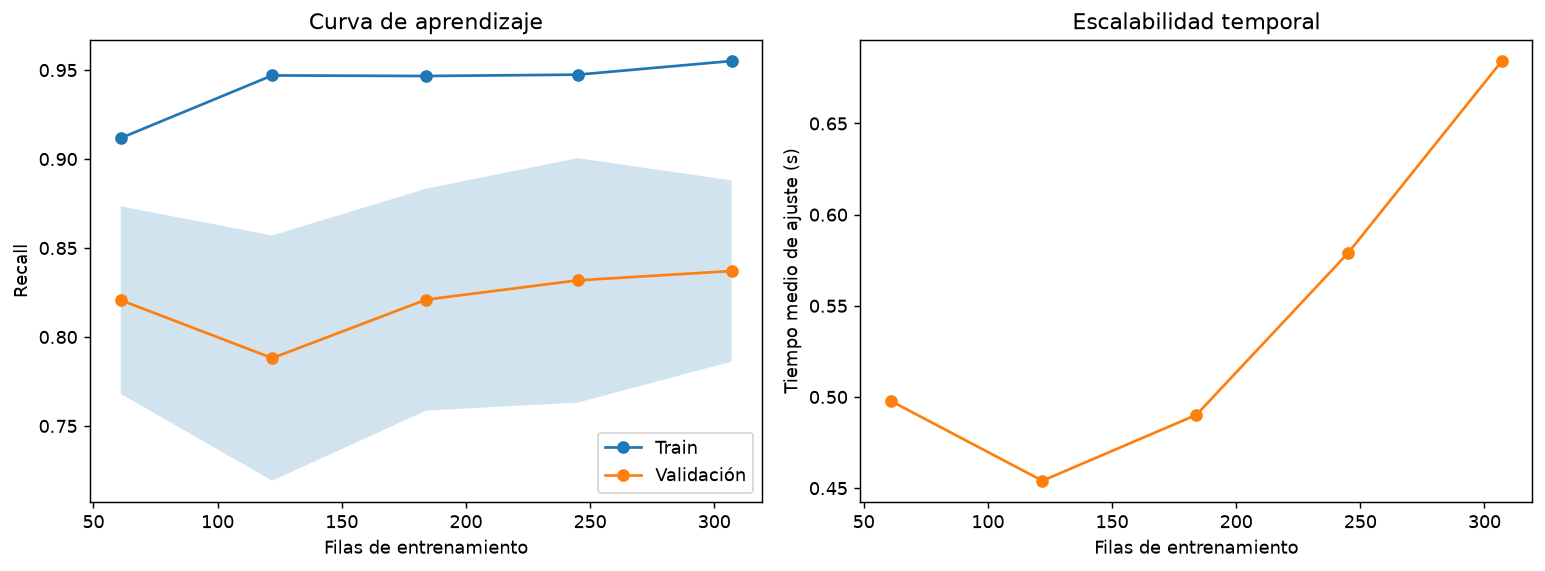

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    learning_summary["train_rows"], learning_summary["train_recall_mean"], marker="o", label="Train"
)
axes[0].plot(
    learning_summary["train_rows"],
    learning_summary["validation_recall_mean"],
    marker="o",
    label="Validación",
)
axes[0].fill_between(
    learning_summary["train_rows"],
    learning_summary["validation_recall_mean"] - learning_summary["validation_recall_std"],
    learning_summary["validation_recall_mean"] + learning_summary["validation_recall_std"],
    alpha=0.2,
)
axes[0].set(xlabel="Filas de entrenamiento", ylabel="Recall", title="Curva de aprendizaje")
axes[0].legend()

axes[1].plot(
    learning_summary["train_rows"],
    learning_summary["fit_time_mean_sec"],
    marker="o",
    color="tab:orange",
)
axes[1].set(
    xlabel="Filas de entrenamiento",
    ylabel="Tiempo medio de ajuste (s)",
    title="Escalabilidad temporal",
)
plt.tight_layout()

La brecha entre train y validación persiste, por lo que el modelo conserva cierta varianza. Sin embargo, el recall de validación se estabiliza en un nivel competitivo y no muestra underfitting. El tiempo de ajuste crece gradualmente en el rango observado; no se extrapola este patrón fuera del tamaño disponible.


## 8. Pruebas y experimentos para la siguiente iteración


In [19]:
experiment_backlog = pd.DataFrame(
    [
        {
            "priority": 1,
            "experiment": "Calibración y selección de umbral",
            "hypothesis": "Un umbral validado inferior a 0,50 puede reducir falsos negativos con un costo aceptable en especificidad.",
            "validation": "CalibratedClassifierCV y búsqueda de umbral dentro de CV anidada.",
        },
        {
            "priority": 2,
            "experiment": "Validación externa y temporal",
            "hypothesis": "El desempeño se mantiene en otra institución, periodo o población.",
            "validation": "Dataset independiente y métricas con intervalos por subgrupo.",
        },
        {
            "priority": 3,
            "experiment": "Mejorar calidad y completitud",
            "hypothesis": "Reducir faltantes, especialmente en falsos positivos, mejora la discriminación.",
            "validation": "Comparar captura completa versus imputación dentro de CV.",
        },
        {
            "priority": 4,
            "experiment": "Estabilidad de atributos",
            "hypothesis": "La importancia de thal y otros atributos es estable y no depende de una sola partición.",
            "validation": "Permutación repetida y bootstrap en múltiples particiones.",
        },
        {
            "priority": 5,
            "experiment": "Evaluación por subgrupos",
            "hypothesis": "Recall y especificidad son comparables por sexo, edad y fuente de datos.",
            "validation": "Métricas estratificadas con tamaños mínimos e intervalos de confianza.",
        },
        {
            "priority": 6,
            "experiment": "Nuevas variables clínicas",
            "hypothesis": "Antecedentes, medicación y contexto temporal explican casos ambiguos.",
            "validation": "Protocolo de recolección, control de leakage y comparación incremental.",
        },
    ]
).set_index("priority")

experiment_backlog

,experiment,hypothesis,validation
priority,,,
1,Calibración y selección de umbral,"Un umbral validado inferior a 0,50 puede reduc...",CalibratedClassifierCV y búsqueda de umbral de...
2,Validación externa y temporal,"El desempeño se mantiene en otra institución, ...",Dataset independiente y métricas con intervalo...
3,Mejorar calidad y completitud,"Reducir faltantes, especialmente en falsos pos...",Comparar captura completa versus imputación de...
4,Estabilidad de atributos,La importancia de thal y otros atributos es es...,Permutación repetida y bootstrap en múltiples ...
5,Evaluación por subgrupos,Recall y especificidad son comparables por sex...,Métricas estratificadas con tamaños mínimos e ...
6,Nuevas variables clínicas,"Antecedentes, medicación y contexto temporal e...","Protocolo de recolección, control de leakage y..."


## ✅ Validaciones finales


In [20]:
final_checks = pd.Series(
    {
        "artifact_loaded_as_pipeline": list(winner_pipeline.named_steps) == ["features", "model"],
        "expected_test_size_reproduced": len(X_test) == EXPECTED_TEST_ROWS,
        "expected_false_negatives_reproduced": fn == EXPECTED_FALSE_NEGATIVES,
        "feature_importance_complete": np.isclose(random_forest.feature_importances_.sum(), 1.0),
        "permutation_uses_original_features": len(permutation_summary) == X_test.shape[1],
        "error_counts_match_test_size": error_profile["observations"].sum() == len(X_test),
        "learning_curve_completed": len(learning_summary) == LEARNING_CURVE_POINTS,
        "experiments_prioritized": experiment_backlog.index.is_monotonic_increasing,
        "model_artifact_not_modified": MODEL_FILE.exists(),
        "no_individual_patient_rows_displayed": True,
    },
    name="passed",
).to_frame()

assert final_checks["passed"].all(), final_checks
final_checks

,passed
artifact_loaded_as_pipeline,True
expected_test_size_reproduced,True
expected_false_negatives_reproduced,True
feature_importance_complete,True
permutation_uses_original_features,True
error_counts_match_test_size,True
learning_curve_completed,True
experiments_prioritized,True
model_artifact_not_modified,True
no_individual_patient_rows_displayed,True


## Conclusiones y recomendaciones

1. **El artefacto es reproducible.** El pipeline cargado conserva recall 0,891, especificidad 0,820, F1 0,854 y ROC AUC 0,927 en las 96 observaciones de test.
2. **`thal` es la señal interpretativa más consistente.** Lidera la importancia por permutación y sus categorías aparecen entre las divisiones de mayor importancia del bosque. Esto no implica causalidad.
3. **Los falsos negativos son pocos pero críticos.** Cinco casos positivos no fueron detectados; varios tienen probabilidad cercana al umbral y patrones menos típicos para la clase positiva.
4. **Los faltantes pueden contribuir a falsos positivos.** Este grupo presenta más predictores faltantes en promedio, aunque la muestra es insuficiente para atribuir causalidad.
5. **No hay evidencia de que el desbalance o los outliers expliquen principalmente los errores.** Las clases están próximas a 50/50 y las señales de outliers son limitadas.
6. **El umbral merece una iteración específica.** La sensibilidad exploratoria muestra que 0,45 reduciría falsos negativos, pero debe validarse exclusivamente dentro de train y después de calibrar las probabilidades.
7. **Antes de uso real:** realizar validación externa y temporal, evaluar desempeño por subgrupos, mejorar completitud de datos y acordar con especialistas el costo aceptable de cada error.

El modelo debe entenderse como una herramienta académica de priorización y no como sustituto del juicio clínico ni como diagnóstico automatizado.
